In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,get_acronym,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [ ]:
# modelA = 'deepseek'
modelA = 'llama'
modelB = modelA
languages = [
            # 'english',
            # 'italian',
            'spanish',
            # 'german',
            ]

batch_shuffle = 0
txt_vars = ['sem']
min_token_length = 5
n_files = 16
batch_size = 100
Ns = batch_size*n_files
n_tokens_list = [min_token_length]
avg_flags = [1]
Nbits_list = [0]
match_vars = ['matching']
centers_list = ['sem']
zero_activations_list = [0,1]

[]

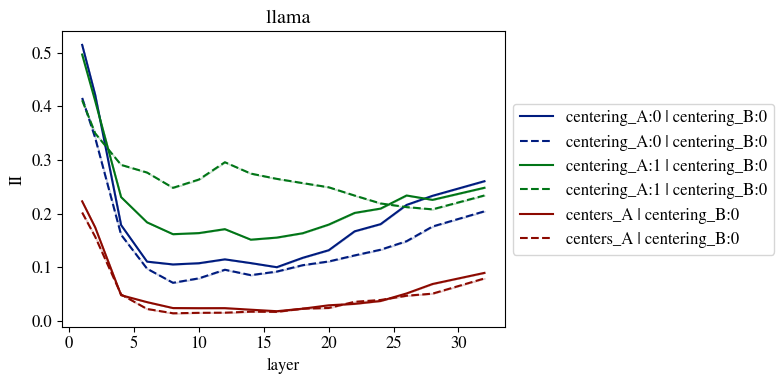

In [15]:
fig,ax = plt.subplots(1,figsize=(8,4))

plot_id = 0
title = ' '

for zero_id,zero_activations in enumerate(zero_activations_list):
  for center_A_id,center_A_flag in enumerate([0,1]):
    for center_B_id,center_B_flag in enumerate([0]):
      if zero_activations == 1 and center_A_flag == 0: continue
      for txt_var_id,txt_var in enumerate(txt_vars):
        for avg_id,avg_tokens in enumerate(avg_flags):
          for centers_id,centers in enumerate(centers_list):
            for match_id,match_var in enumerate(match_vars):
              for Nbits_id,Nbits in enumerate(Nbits_list):
                for language_id, language in enumerate(languages):
                  for n_tokens in n_tokens_list:
                    output_folder0 = makefolder(base=f'./results/',
                                                language=language,
                                                txt_var=txt_var,
                                                modelA=modelA,
                                                modelB=modelB,
                                                match_var=match_var,
                                                n_files=n_files,
                                                min_token_length=min_token_length,
                                                )
                    II_folder = makefolder(base=output_folder0,
                                                      centers=centers,
                                                      Nbits=Nbits,
                                                      n_tokens=n_tokens,
                                                      avg_tokens=avg_tokens,
                                                      batch_shuffle=batch_shuffle,
                                                      zero_activations=zero_activations,
                                                      center_A_flag=center_A_flag,
                                                      center_B_flag=center_B_flag,
                                                      )
                    inf_imb = np.load(II_folder + "II.npy")
                    std = np.load(II_folder + "II_jack_std.npy")

                    layers_A = list(range(1,depths[modelA] + 1))
                    layers_B = list(range(1,depths[modelB] + 1))
                    layers = reduce_list_half_preserve_extremes(layers_A)

                    if 0: 
                      color = colors[plot_id]
                      linestyle = '-'
                      label = f'centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                    if 1: 
                      color = colors[plot_id] 
                      if zero_activations:
                        label = f'centers_A | centering_B:{center_B_flag}'
                      else:
                        label = f'centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                    for II_index in range(2):
                      ax.plot(layers,
                              inf_imb[II_index].diagonal(),
                              label=label,
                              linestyle=_linestyles[II_index],
                              color=color,
                              ) 
                      ax.fill_between(layers,
                                      inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                      inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                      alpha=0.2,
                                      color=color,
                                      )
                    plot_id += 1

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_title(title + f' {modelA}')


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.plot()

### Similarities

In [4]:
# layer_A = 1
# layer_B = 1
# method = 'min'
# sim_folder = makefolder(base=output_folder0+f'similarities/',
#                         create_folder=False,
#                         Nbits=Nbits,
#                         n_tokens=n_tokens,
#                         avg_tokens=avg,
#                         batch_shuffle=batch_shuffle,
#                         layer_A=layer_A,
#                         layer_B=layer_B,
#                         )
# II_fn = build_information_imbalance(k=1)

# A_sim = np.load(os.path.join(sim_folder, "sim_A.npy"))
# B_sim = np.load(os.path.join(sim_folder, "sim_B.npy")) 


In [5]:
A = jnp.array([1,0,2,3,4,5,6])[jnp.array([1,4,6])]
A


Array([0, 4, 6], dtype=int32)